# Task: Correlation

**Student Name:** Mykhailo Andrusiak  
**Country:** Switzerland  
**Semester term:** FS26  


## Day 6 – Data & Domain

### Use Case

In the context of Swiss railway predictive maintenance, vertical bogie vibration signals are generated by wheel-rail contact forces and recorded by onboard accelerometers during SBB train operation in order to detect early signatures of wheel-tread defects before safety-critical failure occurs. These digital signals are used by SBB maintenance teams to monitor the rotational behaviour of wheelsets and to localise discrete impact events that may indicate the onset of a flat spot or a rail surface irregularity. This use case is particularly relevant for Switzerland because high traffic density on limited mainline corridors and strict alpine safety standards require automated, continuous monitoring systems capable of distinguishing normal periodic vibration patterns from fault-induced impulses.

**Українською:**
У контексті предиктивного обслуговування швейцарської залізниці вертикальні вібраційні сигнали візка формуються силами контакту колесо-рейка та реєструються бортовими акселерометрами під час руху поїздів SBB, щоб виявляти ранні ознаки дефектів поверхні кочення колеса до виникнення критичних відмов. Ці цифрові сигнали використовуються командами техобслуговування SBB для контролю ротаційної поведінки колісних пар і локалізації окремих ударних подій, які можуть вказувати на початок повзуна або нерівності рейкової поверхні. Цей кейс особливо актуальний для Швейцарії через високу щільність руху на обмежених магістралях і суворі альпійські вимоги безпеки, що потребують безперервного автоматизованого моніторингу з відокремленням нормальної періодичної вібрації від імпульсів, спричинених дефектами.

### Problem Statement

This project addresses the problem of applying correlation-based analysis — normalised autocorrelation for periodicity quantification and cross-correlation for template-based event localisation — to bogie vibration monitoring within the Swiss SBB predictive maintenance context. If the maximum lag window is chosen too short for autocorrelation, wheel-rotation periodicity peaks fall outside the computed range and the rotation frequency cannot be confirmed; if the cross-correlation template length is chosen too short or too long, detection SNR degrades, leading to either missed defect events or false detections caused by background noise and unrelated vibration modes. Reliably identifying both the wheel rotation rhythm and the location of individual impact events is essential for accurate maintenance scheduling and safety assurance in this application.

**Українською:**
Проєкт вирішує задачу застосування кореляційного аналізу до моніторингу вібрації візка в контексті предиктивного обслуговування SBB: нормована автокореляція використовується для оцінки періодичності, а взаємна кореляція — для локалізації подій за шаблоном. Якщо максимальне вікно лагу для автокореляції занадто коротке, піки періодичності обертання колеса не потрапляють у розрахований діапазон і частоту обертання неможливо підтвердити; якщо довжина шаблону для взаємної кореляції надто мала або надто велика, погіршується SNR детекції, що призводить до пропуску дефектів або хибних спрацювань через шум і сторонні моди вібрації. Надійне визначення як ритму обертання колеса, так і часу окремих ударних подій є критично важливим для точного планування обслуговування та забезпечення безпеки.

### Experimental Objective

The objective of this project is to investigate how the maximum lag window influences autocorrelation peak clarity at multiples of the wheel rotation period, and how template length affects cross-correlation detection SNR, within the context of SBB bogie vibration monitoring. The goal is to determine under which parameter settings correlation analysis reliably distinguishes the wheel rotation rhythm from background vibration and accurately localises individual impulse events in a fixed 1.0-second signal segment.

**Українською:**
Мета проєкту — дослідити, як максимальна довжина вікна лагу впливає на чіткість піків автокореляції на кратних періоду обертання колеса, і як довжина шаблону впливає на SNR детекції у взаємній кореляції в задачі моніторингу вібрацій візка SBB. Підсумкова ціль — визначити такі налаштування параметрів, за яких кореляційний аналіз надійно відділяє ритм обертання колеса від фонової вібрації та точно локалізує окремі імпульсні події у фіксованому 1.0-секундному сегменті сигналу.

### Data Definition, Source, and Visualization

The selected source is a one-dimensional synthetic vertical bogie vibration recording designed to emulate Swiss SBB operating conditions at 80 km/h, expressed in normalised acceleration units [a.u.]. The full source duration is 60 seconds at $f_s = 575\,\text{Hz}$, yielding 34,500 samples. It combines baseline vibration components, periodic defect-like impulse events aligned with wheel rotation, and light additive noise. The data are generated with the project script `generate_synthetic_signal.py` and loaded from `data/synthetic_defect_signal.npy`, with event timestamps stored in `data/synthetic_defect_signal_event_times.npy`. For this correlation study, a fixed 1.0 s analysis segment (575 samples) is used consistently for autocorrelation and cross-correlation evaluation.

Signal path: /Users/workflow/FHNW git/FS2026 git/gbsv/gbsv-research/data/synthetic_defect_signal.npy
Full signal shape: (34500,), dtype: float64
Analysis signal shape (1.0 s): (575,)
Loaded defect event times (all): 461
Defect event times in first 1.0 s: 7
Analysis signal stats: mean=0.0315, std=0.1095, min=-0.2643, max=0.4403


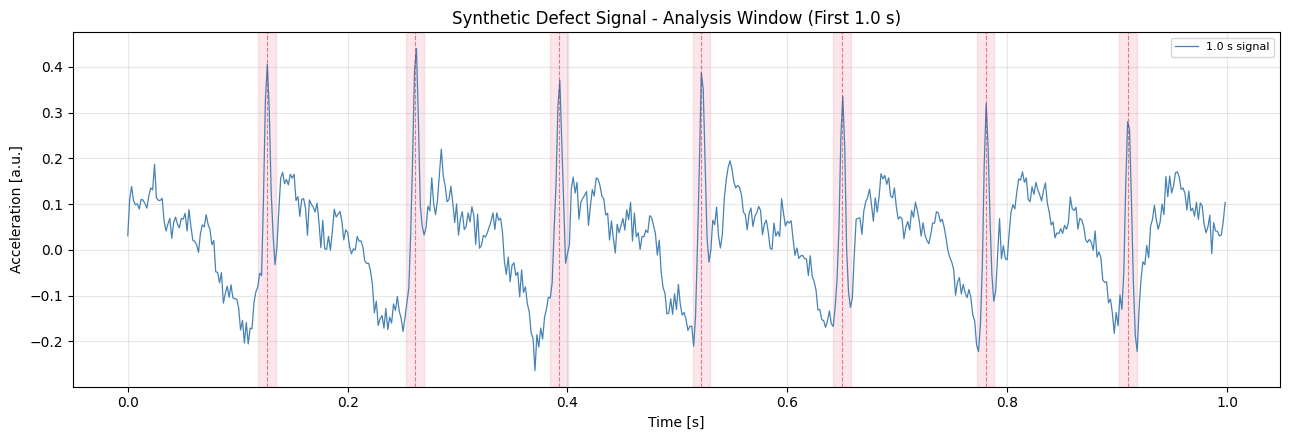

In [4]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

FS_HZ = 575
DURATION_SECONDS = 60
FOCUS_WINDOW_SECONDS = 1.0
EVENT_MARKER_HALF_WIDTH_S = 0.008

project_root = Path.cwd().resolve().parent
x_path = project_root / "data" / "synthetic_defect_signal.npy"
event_path = project_root / "data" / "synthetic_defect_signal_event_times.npy"

x_full = np.load(x_path).astype(np.float64)
event_times = np.load(event_path).astype(np.float64) if event_path.exists() else np.array([], dtype=np.float64)

assert x_full.ndim == 1, "Expected a 1D synthetic signal."
assert x_full.size == FS_HZ * DURATION_SECONDS, "Unexpected signal length for 60 s at 575 Hz."

focus_samples = max(1, int(FS_HZ * FOCUS_WINDOW_SECONDS))
x = x_full[:focus_samples].copy()
time_s = np.arange(x.size) / FS_HZ
event_times_focus = event_times[(event_times >= 0.0) & (event_times < FOCUS_WINDOW_SECONDS)]

print(f"Signal path: {x_path}")
print(f"Full signal shape: {x_full.shape}, dtype: {x_full.dtype}")
print(f"Analysis signal shape (1.0 s): {x.shape}")
print(f"Loaded defect event times (all): {event_times.size}")
print(f"Defect event times in first {FOCUS_WINDOW_SECONDS:.1f} s: {event_times_focus.size}")
print(
    f"Analysis signal stats: mean={x.mean():.4f}, std={x.std():.4f}, "
    f"min={x.min():.4f}, max={x.max():.4f}"
)

fig, ax = plt.subplots(1, 1, figsize=(13, 4.5))
ax.plot(time_s, x, linewidth=0.9, color="steelblue", label="1.0 s signal")

for t_evt in event_times_focus:
    ax.axvspan(
        max(0.0, t_evt - EVENT_MARKER_HALF_WIDTH_S),
        min(FOCUS_WINDOW_SECONDS, t_evt + EVENT_MARKER_HALF_WIDTH_S),
        color="crimson",
        alpha=0.10,
    )
    ax.axvline(t_evt, color="crimson", linestyle="--", linewidth=0.8, alpha=0.55)

ax.set_title("Synthetic Defect Signal - Analysis Window (First 1.0 s)")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Acceleration [a.u.]")
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

**Observations**:
The 1.0 s analysis window shows seven clearly recurring impulse events with inter-peak spacing close to $0.13\,\text{s}$, consistent with the theoretically expected wheel rotation period $T_w \approx 0.1301\,\text{s}$. The selected segment contains representative baseline oscillation, defect-related impulses, and light noise in a compact horizon, making it suitable for direct lag-based periodicity assessment and template-based event localisation under one consistent setup.

## Day 7 – Methodological Design

### Theoretical Foundation and Method Choice

This investigation applies the principle of signal correlation to bogie vibration monitoring for SBB predictive maintenance in Switzerland. The normalised biased autocorrelation $R_{xx}(\tau) = \frac{1}{N\,\sigma_x^2}\sum_{n=0}^{N-1} \tilde{x}(n)\,\tilde{x}(n+\tau)$ (where $\tilde{x} = x - \bar{x}$) quantifies the degree of self-similarity at lag $\tau$, with a distinct positive peak at $\tau = T_w$ indicating the presence of a periodic component at the wheel rotation frequency. The normalised cross-correlation $R_{xy}(\tau) = \frac{1}{N\,\sigma_x\,\sigma_y}\sum_{n} \tilde{x}(n+\tau)\,\tilde{y}(n)$ measures the similarity between the full signal and a short reference template at every time position, enabling precise localisation of events that structurally match the template. Both operations are implemented via `scipy.signal.correlate(mode='full')` with subsequent biased normalisation, which is selected because it preserves the full lag range, supports arbitrary signal and template lengths, and produces output directly interpretable as a correlation coefficient in $[-1, 1]$. If the stationarity assumption is violated by speed changes or track irregularities, peak heights become unreliable indicators of periodicity strength or detection confidence in this maintenance application.

### Parameter Definition and Mathematical Specification

The source signal is sampled at $f_s = 575\,\text{Hz}$; analysis is performed on a fixed window $T_a = 1.0\,\text{s}$, giving $N_a = f_s \cdot T_a = 575$ samples. The wheel rotation frequency is derived from train speed $v = 80\,\text{km/h} = 80/3.6\,\text{m/s}$ and wheel diameter $d = 0.920\,\text{m}$:

$$f_w = \frac{v}{\pi d} \approx 7.69\,\text{Hz}, \quad T_w = \frac{1}{f_w} \approx 0.1301\,\text{s}, \quad L_w = \left\lfloor T_w f_s \right\rceil = 75\,\text{samples}.$$

For autocorrelation, lag limits are set as $\tau_{\max}\in\{0.1,0.5,0.9\}\,\text{s}$. For cross-correlation, the template sweep uses exactly three lengths: $\{10,50,180\}\,\text{ms}$, centered at the largest-amplitude sample within the first 0.5 s. Here, 10 ms is an intentionally too-short template, 50 ms is the working baseline, and 180 ms is an intentionally too-long template. This setup is designed to contrast two adverse regimes against one practical operating point.

### Experimental Design for Next Days

The baseline configuration is defined as autocorrelation with $\tau_{\max} = 0.5\,\text{s}$ and cross-correlation with a 50 ms template centred on the absolute-maximum sample in the first 0.5 s. The following parameters are varied systematically: **(A) maximum lag** for autocorrelation — $\tau_{\max} \in \{0.1\,\text{s},\ 0.5\,\text{s}\ \text{(baseline)},\ 0.9\,\text{s}\}$; **(B) template length** for cross-correlation — $T_{\text{tmpl}} \in \{10\,\text{ms}\ \text{(bad-short)},\ 50\,\text{ms}\ \text{(baseline)},\ 180\,\text{ms}\ \text{(bad-long)}\}$. For autocorrelation, $\tau_{\max}=0.1\,\text{s}<T_w$ is expected to be invalid, while 0.5 s and 0.9 s provide valid periodicity coverage. For cross-correlation, the design intentionally compares two adverse template regimes (too short and too long) against one practical baseline to highlight detection-contrast sensitivity under fixed anchor placement.

### Methodological Limitations and Risk Factors

This setup assumes that a 1.0 s segment is representative of the wheel-synchronous defect pattern and local noise conditions. In short-window analysis, metric values can shift with anchor placement, local transient amplitude, and overlap length at larger lags. Correlation normalisation remains useful for comparability, but isolated high-amplitude impulses can still bias perceived periodicity strength or detection contrast. In the SBB maintenance context, the primary risks are template-anchor sensitivity and limited generalisability from a single short segment to broader operating variability.

## Day 8 – Implementation

f_wheel = 7.6886 Hz | T_wheel = 0.1301 s | L_wheel = 75 samples
Analysis window used in all correlation experiments: 1.000 s
Template anchor: sample 151 (0.2626 s)


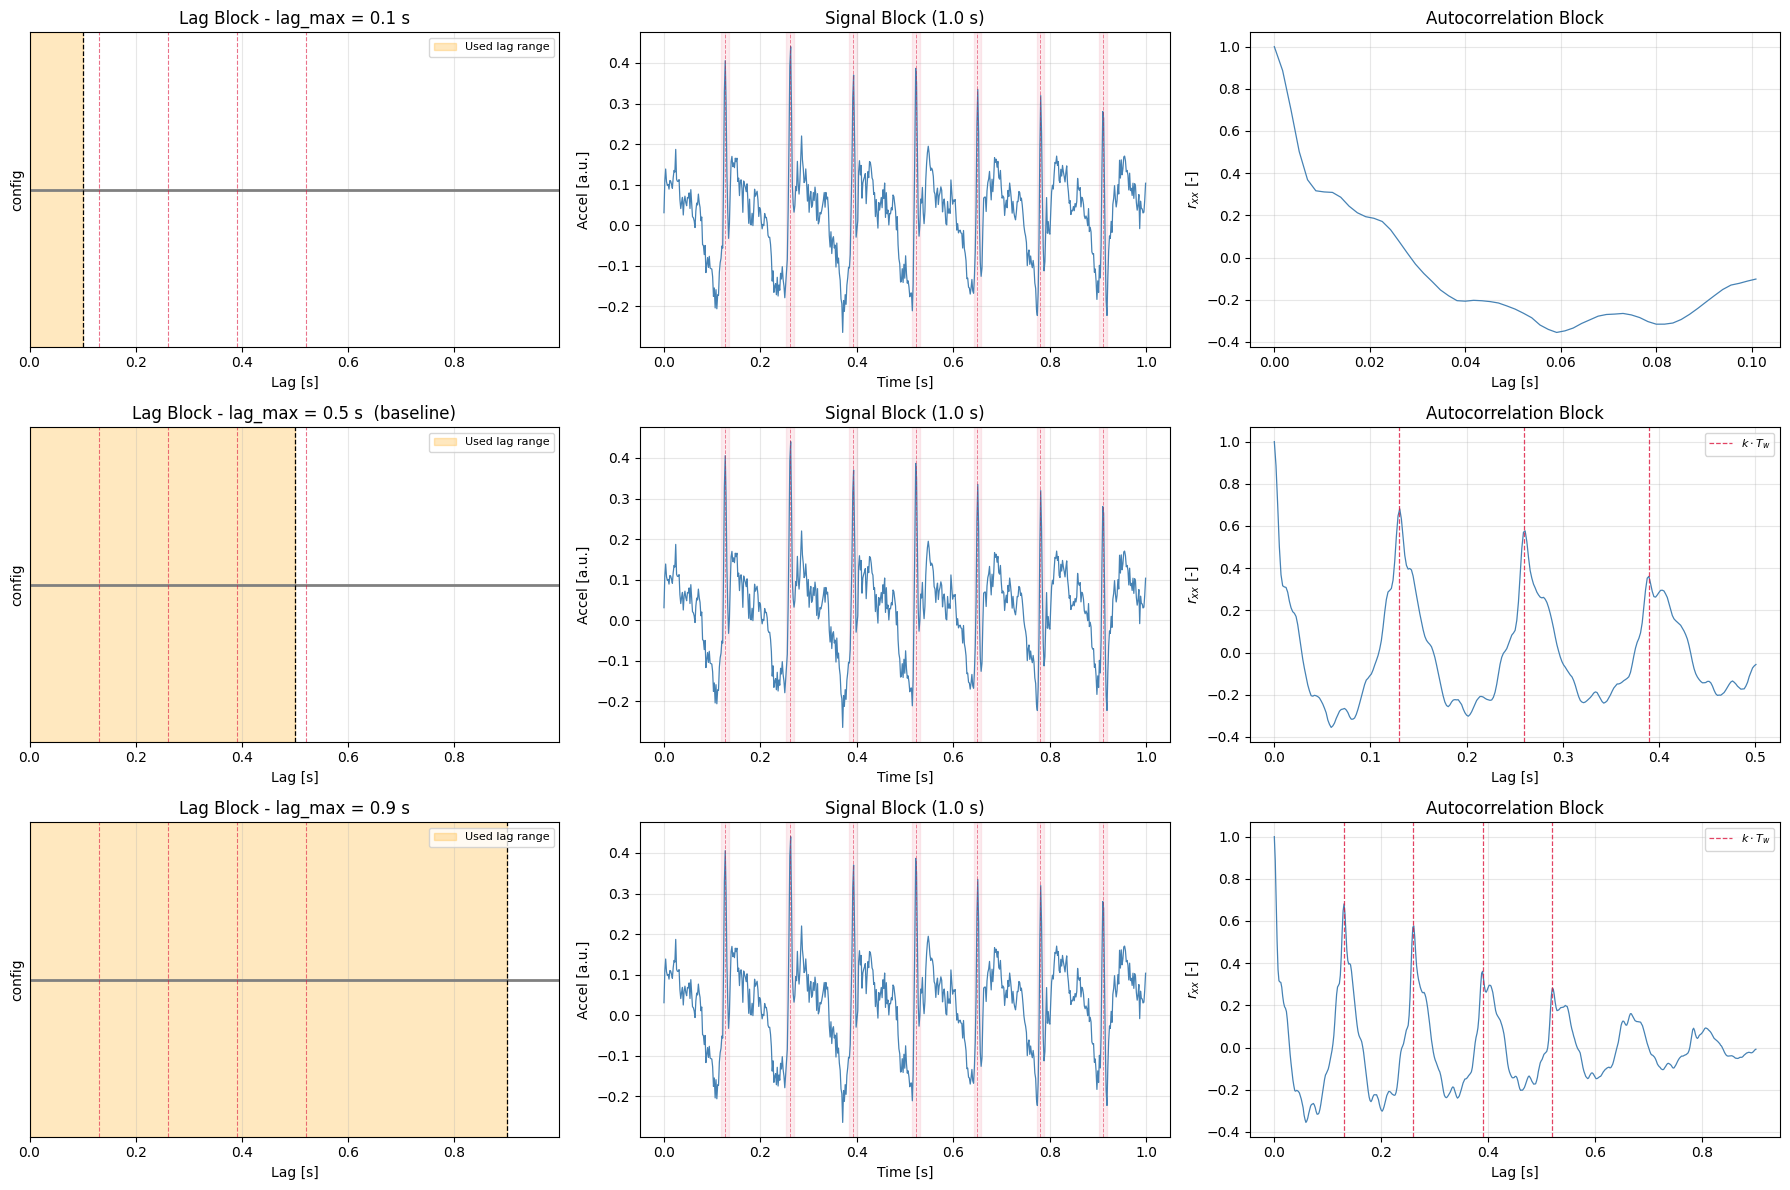

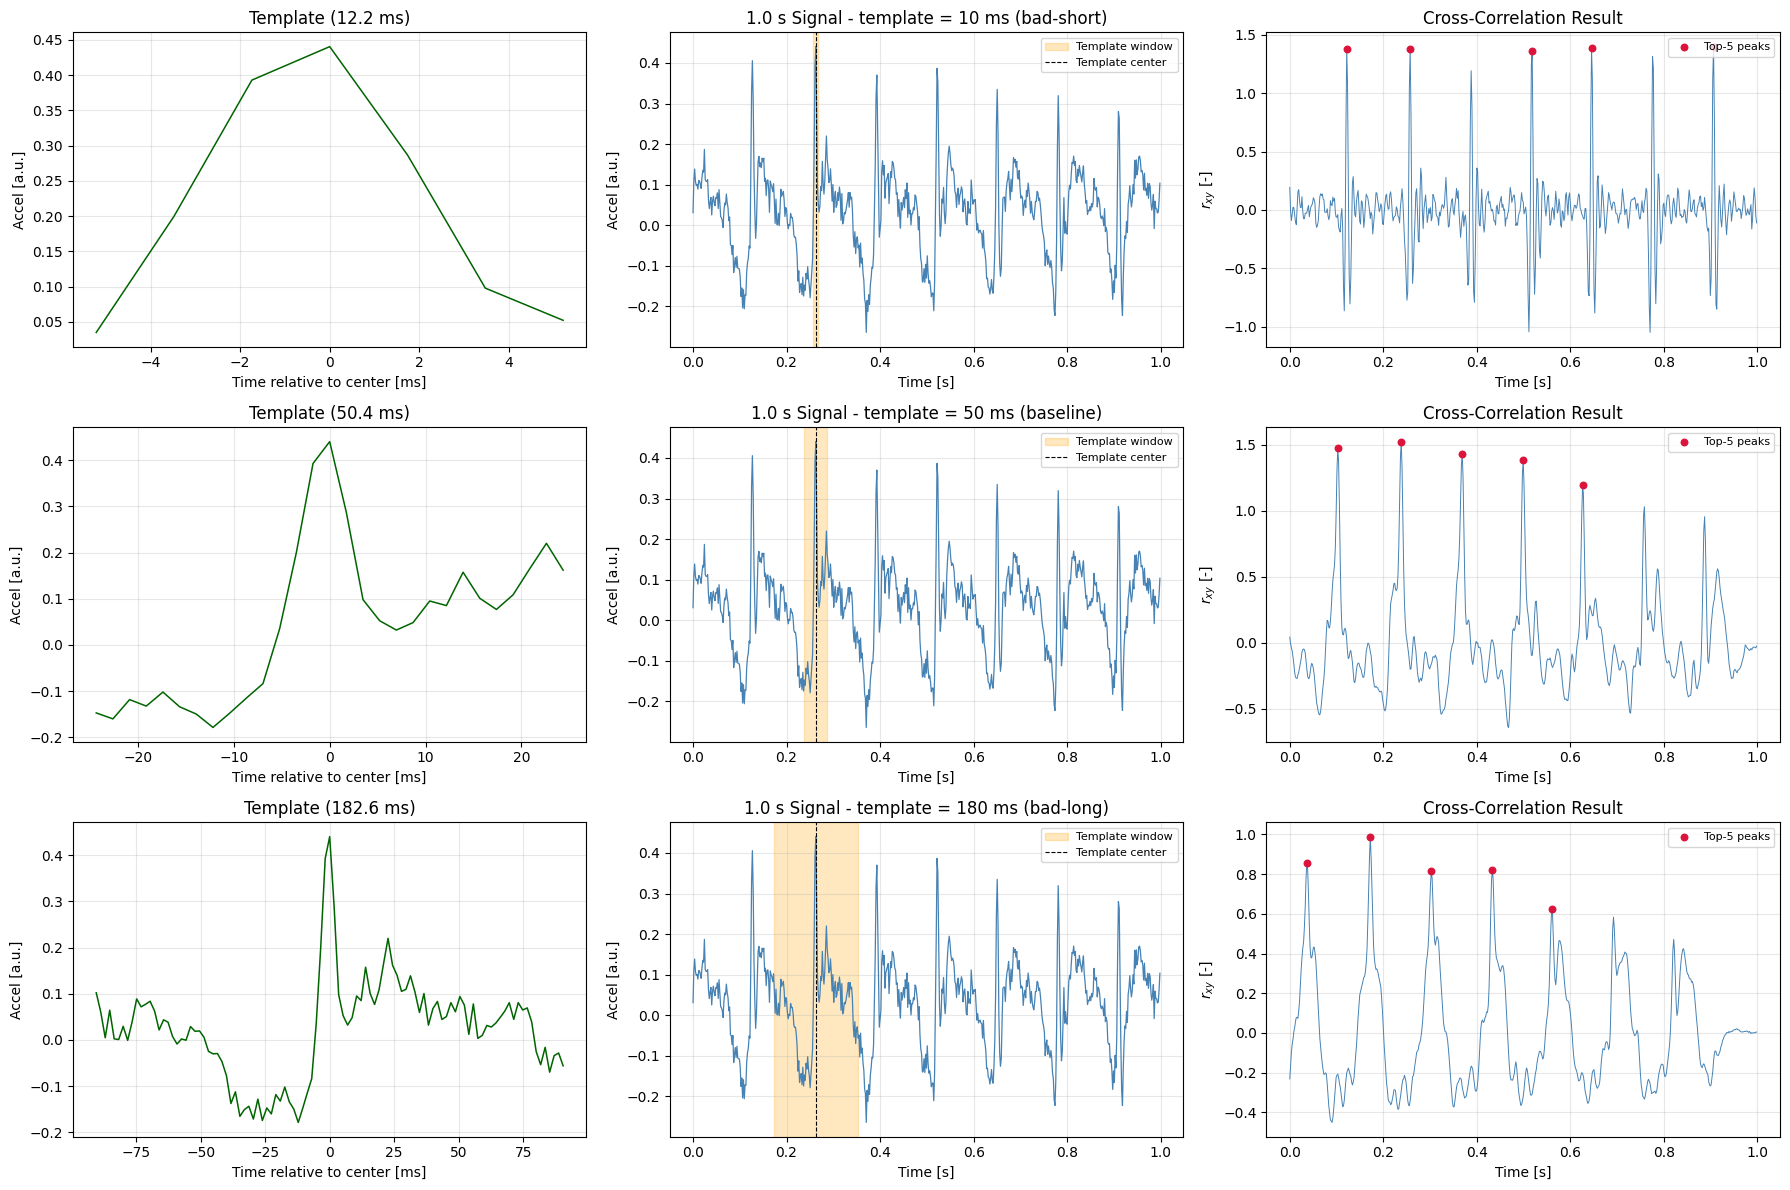

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import correlate, correlation_lags, find_peaks

# Reuse shared constants from Day 6; keep defaults for standalone execution
WHEEL_DIAM_M = 0.920
SPEED_MPS = 80 / 3.6  # 80 km/h -> m/s

f_wheel = SPEED_MPS / (np.pi * WHEEL_DIAM_M)
T_wheel_s = 1.0 / f_wheel
L_wheel_samples = round(T_wheel_s * FS_HZ)

print(f"f_wheel = {f_wheel:.4f} Hz | T_wheel = {T_wheel_s:.4f} s | L_wheel = {L_wheel_samples} samples")
print(f"Analysis window used in all correlation experiments: {x.size / FS_HZ:.3f} s")


def compute_autocorr(signal: np.ndarray, lag_max_s: float, fs: int):
    """Normalised biased autocorrelation; r[0] = 1.0."""
    xc = signal - signal.mean()
    r_full = correlate(xc, xc, mode="full")
    lags_full = correlation_lags(xc.size, xc.size, mode="full")
    r_norm = r_full / (xc.size * xc.var())
    centre = xc.size - 1
    lag_max_samp = round(lag_max_s * fs)
    return (
        r_norm[centre : centre + lag_max_samp + 1],
        lags_full[centre : centre + lag_max_samp + 1] / fs,
    )


def extract_template(signal: np.ndarray, center: int, half_len: int) -> np.ndarray:
    start = max(0, center - half_len)
    end = min(signal.size, center + half_len + 1)
    return signal[start:end].copy()


def compute_xcorr_norm(signal: np.ndarray, template: np.ndarray) -> np.ndarray:
    """Normalised cross-correlation aligned to signal time axis."""
    xc = signal - signal.mean()
    tc = template - template.mean()
    r_full = correlate(xc, tc, mode="full")
    norm = template.size * xc.std() * (tc.std() + 1e-12)
    r_norm = r_full / norm
    offset = template.size - 1
    return r_norm[offset : offset + signal.size]


def evaluate_autocorr_configs(signal: np.ndarray, fs: int, T_wheel_s: float, configs):
    records = []
    for cfg in configs:
        r, lags = compute_autocorr(signal, cfg["lag_max_s"], fs)
        r_1 = float(r[np.argmin(np.abs(lags - T_wheel_s))]) if cfg["lag_max_s"] >= T_wheel_s else float("nan")
        r_2 = float(r[np.argmin(np.abs(lags - 2 * T_wheel_s))]) if cfg["lag_max_s"] >= 2 * T_wheel_s else float("nan")
        records.append(
            {
                "config": cfg["label"],
                "lag_max_s": cfg["lag_max_s"],
                "r_at_T_wheel": r_1,
                "r_at_2T_wheel": r_2,
            }
        )

    df = pd.DataFrame(records)
    baseline_r1 = float(df.loc[df["config"].str.contains("baseline"), "r_at_T_wheel"].iloc[0])
    df["rel_change_pct"] = (df["r_at_T_wheel"] - baseline_r1) / (abs(baseline_r1) + 1e-12) * 100.0
    return df


def evaluate_xcorr_configs(signal: np.ndarray, fs: int, template_center: int, configs):
    records = []
    for cfg in configs:
        template = extract_template(signal, template_center, cfg["half_len"])
        r = compute_xcorr_norm(signal, template)
        peak_snr = float(r.max() / (np.mean(np.abs(r)) + 1e-12))
        tlen_ms = int(round((2 * cfg["half_len"] + 1) / fs * 1000))
        records.append(
            {
                "config": cfg["label"],
                "template_length_ms": tlen_ms,
                "peak_snr": peak_snr,
            }
        )

    df = pd.DataFrame(records)
    baseline_snr = float(df.loc[df["config"].str.contains("baseline"), "peak_snr"].iloc[0])
    df["rel_change_pct"] = (df["peak_snr"] - baseline_snr) / (baseline_snr + 1e-12) * 100.0
    return df


def plot_autocorr_triptych_sweep(
    signal: np.ndarray,
    time_s: np.ndarray,
    fs: int,
    T_wheel_s: float,
    configs,
    event_times_s: np.ndarray | None = None,
):
    fig, axes = plt.subplots(len(configs), 3, figsize=(18, 4.0 * len(configs)))
    if len(configs) == 1:
        axes = np.array([axes])

    if event_times_s is None:
        event_times_s = np.array([], dtype=np.float64)

    for row, cfg in enumerate(configs):
        lag_max_s = cfg["lag_max_s"]
        r, lags = compute_autocorr(signal, lag_max_s, fs)

        # Block 1: Lag configuration
        axes[row, 0].hlines(0.0, 0.0, time_s[-1], color="gray", linewidth=2.0)
        axes[row, 0].axvspan(0.0, lag_max_s, color="orange", alpha=0.25, label="Used lag range")
        axes[row, 0].axvline(lag_max_s, color="black", linestyle="--", linewidth=0.9)
        for k in range(1, 5):
            t_k = k * T_wheel_s
            if t_k <= time_s[-1]:
                axes[row, 0].axvline(t_k, color="crimson", linestyle="--", linewidth=0.8, alpha=0.6)
        axes[row, 0].set_xlim(0.0, time_s[-1])
        axes[row, 0].set_ylim(-1.0, 1.0)
        axes[row, 0].set_title(f"Lag Block - {cfg['label']}")
        axes[row, 0].set_xlabel("Lag [s]")
        axes[row, 0].set_ylabel("config")
        axes[row, 0].set_yticks([])
        axes[row, 0].legend(fontsize=8, loc="upper right")
        axes[row, 0].grid(alpha=0.3)

        # Block 2: Signal
        axes[row, 1].plot(time_s, signal, linewidth=0.9, color="steelblue")
        for t_evt in event_times_s:
            axes[row, 1].axvspan(
                max(0.0, t_evt - EVENT_MARKER_HALF_WIDTH_S),
                min(time_s[-1], t_evt + EVENT_MARKER_HALF_WIDTH_S),
                color="crimson",
                alpha=0.08,
            )
            axes[row, 1].axvline(t_evt, color="crimson", linestyle="--", linewidth=0.7, alpha=0.5)
        axes[row, 1].set_title("Signal Block (1.0 s)")
        axes[row, 1].set_xlabel("Time [s]")
        axes[row, 1].set_ylabel("Accel [a.u.]")
        axes[row, 1].grid(alpha=0.3)

        # Block 3: Autocorrelation
        axes[row, 2].plot(lags, r, linewidth=0.9, color="steelblue")
        markers_added = 0
        for k in range(1, 5):
            t_k = k * T_wheel_s
            if t_k <= lag_max_s:
                label = "$k \\cdot T_w$" if markers_added == 0 else None
                axes[row, 2].axvline(t_k, color="crimson", linestyle="--", linewidth=0.9, alpha=0.8, label=label)
                markers_added += 1
        axes[row, 2].set_title("Autocorrelation Block")
        axes[row, 2].set_xlabel("Lag [s]")
        axes[row, 2].set_ylabel("$r_{xx}$ [-]")
        if markers_added > 0:
            axes[row, 2].legend(fontsize=8, loc="upper right")
        axes[row, 2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_xcorr_triptych_sweep(
    signal: np.ndarray,
    time_s: np.ndarray,
    template_center: int,
    configs,
    L_wheel_samples: int,
    fs: int,
):
    fig, axes = plt.subplots(len(configs), 3, figsize=(18, 4.0 * len(configs)))
    if len(configs) == 1:
        axes = np.array([axes])

    for row, cfg in enumerate(configs):
        template = extract_template(signal, template_center, cfg["half_len"])
        r = compute_xcorr_norm(signal, template)
        tlen_samp = 2 * cfg["half_len"] + 1
        tlen_ms = tlen_samp / fs * 1000.0

        peaks, _ = find_peaks(r, distance=max(1, L_wheel_samples // 2))
        top5 = peaks[np.argsort(r[peaks])[::-1][:5]] if peaks.size >= 5 else peaks

        t_template_ms = (np.arange(template.size) - cfg["half_len"]) / fs * 1000.0
        axes[row, 0].plot(t_template_ms, template, color="darkgreen", linewidth=1.1)
        axes[row, 0].set_title(f"Template ({tlen_ms:.1f} ms)")
        axes[row, 0].set_xlabel("Time relative to center [ms]")
        axes[row, 0].set_ylabel("Accel [a.u.]")
        axes[row, 0].grid(alpha=0.3)

        start_idx = max(0, template_center - cfg["half_len"])
        end_idx = min(signal.size - 1, template_center + cfg["half_len"])
        axes[row, 1].plot(time_s, signal, linewidth=0.9, color="steelblue")
        axes[row, 1].axvspan(start_idx / fs, end_idx / fs, color="orange", alpha=0.25, label="Template window")
        axes[row, 1].axvline(template_center / fs, color="black", linestyle="--", linewidth=0.8, label="Template center")
        axes[row, 1].set_title(f"1.0 s Signal - {cfg['label']}")
        axes[row, 1].set_xlabel("Time [s]")
        axes[row, 1].set_ylabel("Accel [a.u.]")
        axes[row, 1].legend(fontsize=8, loc="upper right")
        axes[row, 1].grid(alpha=0.3)

        axes[row, 2].plot(time_s[: r.size], r, linewidth=0.7, color="steelblue")
        axes[row, 2].scatter(
            time_s[top5],
            r[top5],
            color="crimson",
            zorder=5,
            s=22,
            label="Top-5 peaks",
        )
        axes[row, 2].set_title("Cross-Correlation Result")
        axes[row, 2].set_xlabel("Time [s]")
        axes[row, 2].set_ylabel("$r_{xy}$ [-]")
        axes[row, 2].legend(fontsize=8, loc="upper right")
        axes[row, 2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_baseline_comparison(
    signal: np.ndarray,
    time_s: np.ndarray,
    fs: int,
    T_wheel_s: float,
    template_center: int,
    L_wheel_samples: int,
    autocorr_lag_max_s: float = 0.5,
    xcorr_half_len: int = round(0.025 * FS_HZ),
):
    fig, axes = plt.subplots(2, 2, figsize=(15, 9))

    r_base, lags_base = compute_autocorr(signal, autocorr_lag_max_s, fs)
    axes[0, 0].plot(lags_base, r_base, linewidth=0.9, color="steelblue")
    for k in range(1, 5):
        t_k = k * T_wheel_s
        if t_k <= autocorr_lag_max_s:
            axes[0, 0].axvline(t_k, color="crimson", linestyle="--", linewidth=1.0, label=f"$k={k}$")
    axes[0, 0].set_title("Baseline Autocorrelation (1.0 s signal)")
    axes[0, 0].set_xlabel("Lag [s]")
    axes[0, 0].set_ylabel("$r_{xx}$ [-]")
    axes[0, 0].legend(fontsize=8, ncol=4, title="$k \\cdot T_w$")
    axes[0, 0].grid(alpha=0.3)

    template_base = extract_template(signal, template_center, xcorr_half_len)
    t_template_ms = (np.arange(template_base.size) - xcorr_half_len) / fs * 1000.0
    axes[0, 1].plot(t_template_ms, template_base, color="darkgreen", linewidth=1.1)
    axes[0, 1].set_title("Baseline Template (50 ms)")
    axes[0, 1].set_xlabel("Time relative to center [ms]")
    axes[0, 1].set_ylabel("Accel [a.u.]")
    axes[0, 1].grid(alpha=0.3)

    start_idx = max(0, template_center - xcorr_half_len)
    end_idx = min(signal.size - 1, template_center + xcorr_half_len)
    axes[1, 0].plot(time_s, signal, linewidth=0.9, color="steelblue")
    axes[1, 0].axvspan(start_idx / fs, end_idx / fs, color="orange", alpha=0.25, label="Template window")
    axes[1, 0].axvline(template_center / fs, color="black", linestyle="--", linewidth=0.8, label="Template center")
    axes[1, 0].set_title("1.0 s Signal with Baseline Template")
    axes[1, 0].set_xlabel("Time [s]")
    axes[1, 0].set_ylabel("Accel [a.u.]")
    axes[1, 0].legend(fontsize=8, loc="upper right")
    axes[1, 0].grid(alpha=0.3)

    r_xcorr = compute_xcorr_norm(signal, template_base)
    all_peaks, _ = find_peaks(r_xcorr, distance=max(1, L_wheel_samples // 2))
    top5 = all_peaks[np.argsort(r_xcorr[all_peaks])[::-1][:5]] if all_peaks.size >= 5 else all_peaks
    axes[1, 1].plot(time_s[: r_xcorr.size], r_xcorr, linewidth=0.7, color="steelblue")
    axes[1, 1].scatter(
        time_s[top5],
        r_xcorr[top5],
        color="crimson",
        zorder=5,
        s=24,
        label="Top-5 peaks",
    )
    axes[1, 1].set_title("Baseline Cross-Correlation Result")
    axes[1, 1].set_xlabel("Time [s]")
    axes[1, 1].set_ylabel("$r_{xy}$ [-]")
    axes[1, 1].legend(fontsize=8, loc="upper right")
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


AUTOCORR_CONFIGS = [
    {"label": "lag_max = 0.1 s", "lag_max_s": 0.1},
    {"label": "lag_max = 0.5 s  (baseline)", "lag_max_s": 0.5},
    {"label": "lag_max = 0.9 s", "lag_max_s": 0.9},
]

XCORR_CONFIGS = [
    {"label": "template = 10 ms (bad-short)", "half_len": round(0.005 * FS_HZ)},
    {"label": "template = 50 ms (baseline)", "half_len": round(0.025 * FS_HZ)},
    {"label": "template = 180 ms (bad-long)", "half_len": round(0.090 * FS_HZ)},
]

# Template anchor: largest-amplitude sample in the first 0.5 s (inside 1.0 s analysis signal)
template_center = int(np.argmax(np.abs(x[: round(0.5 * FS_HZ)])))
print(f"Template anchor: sample {template_center} ({template_center / FS_HZ:.4f} s)")

# Part A: Autocorrelation triptych sweep: lag + signal + correlation
plot_autocorr_triptych_sweep(
    x,
    time_s,
    FS_HZ,
    T_wheel_s,
    AUTOCORR_CONFIGS,
    event_times_s=event_times_focus,
)

# Part B: Cross-correlation triptych sweep: template + signal + result
plot_xcorr_triptych_sweep(x, time_s, template_center, XCORR_CONFIGS, L_wheel_samples, FS_HZ)

## Day 9 – Evaluation

### Evaluation Approach Definition

Two quantitative metrics are defined for consistent evaluation across all parameter configurations. **Metric 1 (Autocorrelation peak height):** the normalised autocorrelation value $r_{xx}(\tau)$ sampled at $\tau = T_w$ and $\tau = 2\,T_w$, which directly quantifies how clearly the wheel rotation periodicity is expressed at its fundamental and first harmonic lag; a higher value indicates stronger and more reliable periodicity detection. This metric is appropriate because the problem statement requires confirmation of the wheel rotation period, and the peak height at $\tau = T_w$ directly reflects whether this period is expressed in the signal and whether the lag window is sufficient to observe it.

**Metric 2 (Cross-correlation peak SNR):** $\mathrm{SNR} = r_{xy,\max} / \langle |r_{xy}| \rangle$, computed over the 1.0 s cross-correlation output, which quantifies the contrast between the highest-matching event and the average background correlation level; a higher SNR indicates more confident and less ambiguous defect event localisation. The validity of this metric depends on the template being placed at a genuine impulse event, which must hold for the SNR to meaningfully reflect detection performance in this application.

### Evaluation Comparison Execution

The influence of the maximum lag window ($\tau_{\max} \in \{0.1\,\text{s},\,0.5\,\text{s},\,0.9\,\text{s}\}$) is evaluated using Metric 1 sampled at $T_w$ and $2\,T_w$; configurations where $\tau_{\max} < T_w$ yield NaN, quantifying the information loss from a truncated lag range. The influence of template length is evaluated with exactly three configurations: $T_{\text{tmpl}} \in \{10\,\text{ms},\,50\,\text{ms},\,180\,\text{ms}\}$, where 50 ms is the baseline and the other two are intentionally adverse examples. All metrics are computed on the same fixed 1.0 s signal segment using the same helper functions defined in Day 8, ensuring full comparability. Results are reported in structured printed tables with relative performance change to the baseline, and confirmed by comparative visualisations.

Autocorrelation Evaluation Table
                     config  lag_max_s  r_at_T_wheel  r_at_2T_wheel  rel_change_pct
            lag_max = 0.1 s     0.1000           NaN            NaN             NaN
lag_max = 0.5 s  (baseline)     0.5000        0.6811         0.5765          0.0000
            lag_max = 0.9 s     0.9000        0.6811         0.5765          0.0000

Cross-Correlation Evaluation Table
                      config  template_length_ms  peak_snr  rel_change_pct
template = 10 ms (bad-short)                  12    8.6554         51.2490
 template = 50 ms (baseline)                  50    5.7226          0.0000
template = 180 ms (bad-long)                 183    4.1318        -27.7980



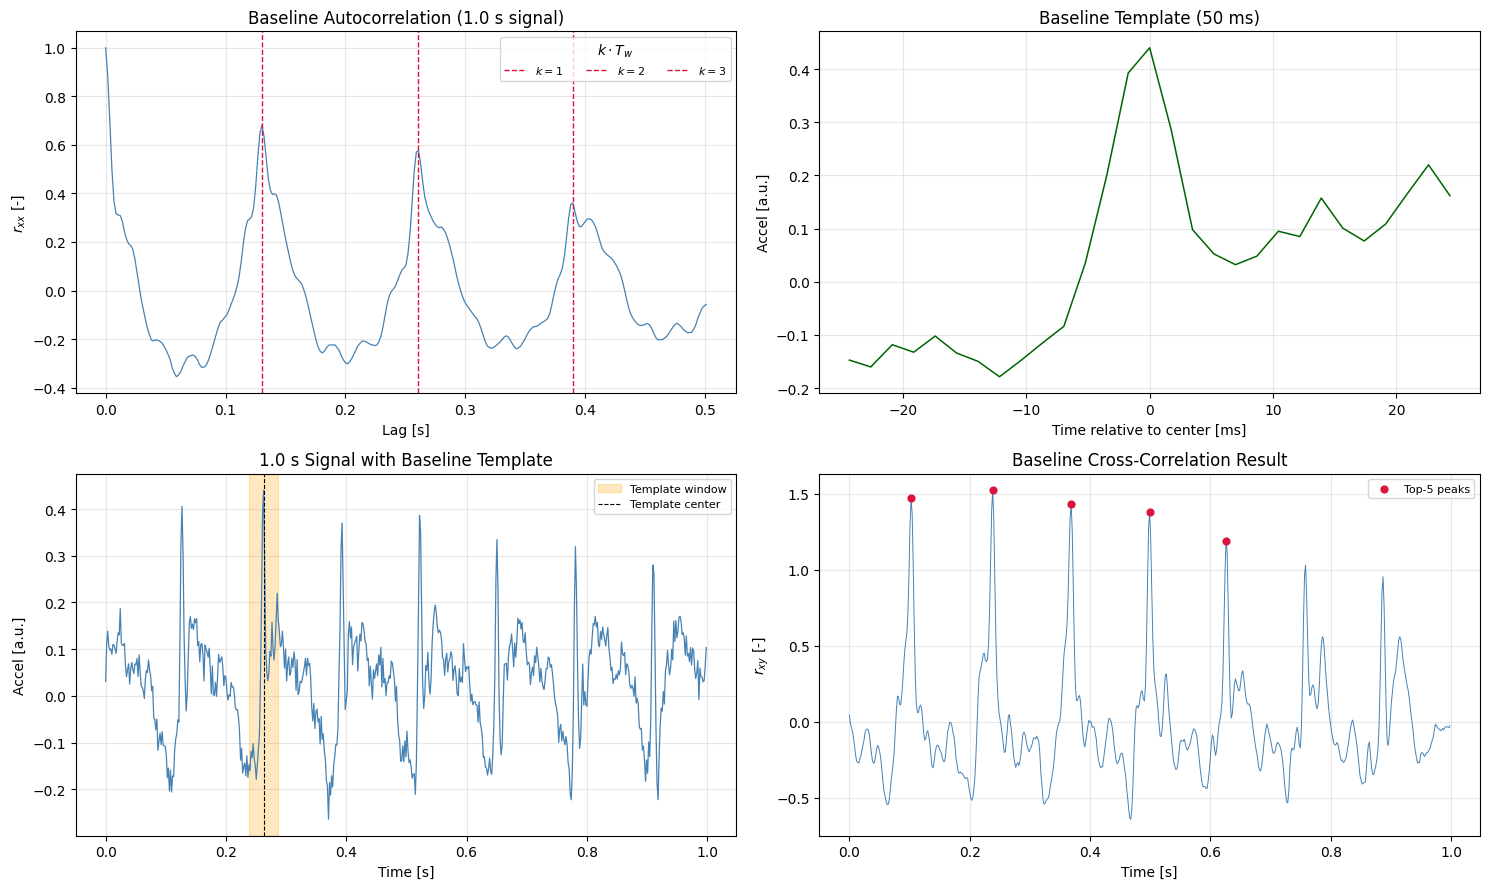

In [8]:
# Metric 1: Autocorrelation peak heights at T_wheel and 2*T_wheel
autocorr_df = evaluate_autocorr_configs(x, FS_HZ, T_wheel_s, AUTOCORR_CONFIGS)
print("Autocorrelation Evaluation Table")
print(autocorr_df.to_string(index=False, float_format="{:.4f}".format))
print()

# Metric 2: Cross-correlation peak SNR
xcorr_df = evaluate_xcorr_configs(x, FS_HZ, template_center, XCORR_CONFIGS)
print("Cross-Correlation Evaluation Table")
print(xcorr_df.to_string(index=False, float_format="{:.4f}".format))
print()

# Comparative visualisation (baseline)
plot_baseline_comparison(
    signal=x,
    time_s=time_s,
    fs=FS_HZ,
    T_wheel_s=T_wheel_s,
    template_center=template_center,
    L_wheel_samples=L_wheel_samples,
)

## Day 10 – Analysis & Communication

### Observations

Autocorrelation results remain unchanged: $\tau_{\max}=0.1\,\text{s}$ yields NaN for both $r_{xx}(T_w)$ and $r_{xx}(2T_w)$ because the lag horizon is shorter than $T_w\approx0.1301\,\text{s}$. For valid lag ranges ($0.5\,\text{s}$ and $0.9\,\text{s}$), periodicity metrics are stable and equal: $r_{xx}(T_w)=0.6811$ and $r_{xx}(2T_w)=0.5765$. With the three-template sweep, peak SNR values are $8.6554$ (12 ms, bad-short), $5.7226$ (50 ms baseline), and $4.1318$ (183 ms, bad-long). Relative to baseline, this corresponds to $+51.25\%$ for 12 ms and $-27.80\%$ for 183 ms.

### Interpretation

In this 1.0 s setup, lag validation is still physically consistent: periodicity cannot be confirmed when $\tau_{\max}<T_w$, while 0.5 s and 0.9 s provide stable periodicity checkpoints. For cross-correlation, the long template behaves as expected (lower SNR due to reduced specificity), but the very short template produces the highest peak-SNR value. This indicates that peak-SNR alone can favor sharp local matches and does not automatically mean better practical detection quality. Therefore, 50 ms remains the balanced working configuration, while 12 ms should be treated as an aggressive high-contrast but potentially over-sensitive regime.

### Discussion and Critical Reflection

The three-template design (bad-short, baseline, bad-long) successfully exposes sensitivity of the chosen cross-correlation metric. It confirms one expected boundary (bad-long degrades contrast) and reveals an important diagnostic caveat (bad-short can inflate peak-SNR). This is methodologically useful: it shows that template quality must be judged not only by a single scalar peak metric, but also by waveform interpretability and robustness to false positives. The notebook is therefore well-suited for controlled parameter benchmarking, while operational deployment should combine SNR with additional quality criteria on labeled real-world data.